# Mellinguer low level controller test
Implement a force estimator for the object force as an external constant force.

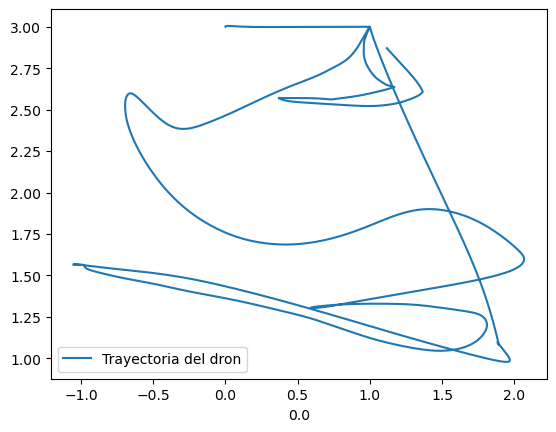

In [2]:
import numpy as np
import mujoco
from mujoco import viewer
import time
from low_level_controller.mellinguer import MellinguerController
from low_level_controller.indi import INDIController
from helper import ForceArrow, quat_to_rotmat
from plot import plot_trajectory

from acceleration_estimator import AccelerationEstimator
from force_observer.force_observer import ForceObserver
from force_observer.force_filter import MovingAverageForgettingFactorFilter




# --- XML con actuadores directos u1,u2,u3,u4 ---
XML_PATH = "system/single_quadrotor_u1234.xml"  # <-- pon aquí tu nuevo XML

model = mujoco.MjModel.from_xml_path(XML_PATH)
data = mujoco.MjData(model)
dt = model.opt.timestep

arrowVF = ForceArrow(model, data, arrow_idx=1) # virtual force (mocap)
arrowEF = ForceArrow(model, data, arrow_idx=2) # estimated force (mocap)

# Body del dron
drone_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "core")
if drone_id < 0:
    raise ValueError("No existe el body 'core' en el XML.")

# Masa total del dron
m = float(model.body_subtreemass[drone_id])

# Posición inicial para hover
mujoco.mj_forward(model, data)
p0 = data.xpos[drone_id].copy()

# Gains como lista: [Kp_pos, Kv_pos, KR_att, Komega_att]
gains = [
    np.array([5.0, 5.0, 10.0]),         # Kp posición (diag)
    np.array([3.0, 3.0, 6.0]),          # Kv velocidad (diag)
    np.array([8.0, 8.0, 2.0]),    # KR actitud (diag)
    np.array([0.2, 0.2, 0.1])         # Komega velocidad angular (diag)
]

controller = MellinguerController(mass=m, gravity=9.81, gains=gains)


# (Opcional) si quieres asignar por nombre para evitar depender del orden:
act_u1 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u1_thrust")
act_u2 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u2_tau_x")
act_u3 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u3_tau_y")
act_u4 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u4_tau_z")
if min(act_u1, act_u2, act_u3, act_u4) < 0:
    raise ValueError("No encontré actuadores u1_thrust/u2_tau_x/u3_tau_y/u4_tau_z. Revisa el XML.")


# Inicializar estimador de aceleración, observador de fuerza y filtro de fuerza
acceleration_estimator = AccelerationEstimator(dt)
force_observer = ForceObserver(drone_mass=m, gravity=9.81)
force_filter = MovingAverageForgettingFactorFilter(window_size=5, forgetting_factor=0.9)


# guardar para debug/visualización
vector_r = []
vector_rT = []
rT = p0.copy()  # referencia inicial

with viewer.launch_passive(model, data) as vis:
    t = 0.0

    while vis.is_running():
        # ---------------------------
        # (1) Leer estado en MuJoCo
        # ---------------------------
        r = data.xpos[drone_id].copy()
        q = data.xquat[drone_id].copy()
        R = quat_to_rotmat(q)

        # guardar para debug/visualización
        vector_r.append(r)
        vector_rT.append(rT)

        # cvel = [wx, wy, wz, vx, vy, vz] (world-aligned)
        cvel = data.cvel[drone_id].copy()
        omega_world = cvel[0:3]
        vel_world = cvel[3:6]

        # aceleración estimada (derivada numérica)
        a = acceleration_estimator.estimate(vel_world, noise=True, noise_std=1.5)

        # Tu controlador típicamente usa omega en body
        omega_body = R.T @ omega_world

        # ---------------------------
        # (2) Referencia deseada (ejemplo: oscilación en x)
        # ---------------------------
        x_d = 1 #0.5 * np.sin(0.5 * t)
        x_dot_d = 0 #0.25 * np.cos(0.5 * t)
        x_ddot_d = 0 #-0.125 * np.sin(0.5 * t)

        rT = np.array([p0[0] + x_d, p0[1], p0[2]])
        vT = np.array([x_dot_d, 0.0, 0.0])
        aT = np.array([x_ddot_d, 0.0, 0.0])

        yaw_d = 0.0

        # ---------------------------
        # (3) Control Mellinger -> u = [u1,u2,u3,u4]
        # ---------------------------

        u, Fv, _ = controller.step(rT, vT, aT, r, vel_world, a, R, omega_body, yaw_d)

        Fe = force_observer.observe(u1_sclr=u[0], drone_acceleration=a, R=R)
        Fe_filt = force_filter.filter(Fe)

        # ---------------------------
        # (4) Aplicar controles directo a actuadores
        # ---------------------------
        data.ctrl[act_u1] = u[0]
        data.ctrl[act_u2] = u[1]
        data.ctrl[act_u3] = u[2]
        data.ctrl[act_u4] = u[3]

        # ---------------------------
        # (5) Actualizar flechas de fuerza / estimar fuerza real
        # ---------------------------

        if arrowVF is not None:
            arrowVF.update_force_arrow_mocap(p0_world=r, F_world=Fv, scale=0.03, max_len=0.8, radius=0.01)

        if arrowEF is not None:
            arrowEF.update_force_arrow_mocap(p0_world=r, F_world=Fe_filt, scale=0.03, max_len=0.8, radius=0.01)

        # ---------------------------
        # (6) Paso de simulación
        # ---------------------------
        start = time.time()

        mujoco.mj_step(model, data)
        vis.sync()
        t += dt

        # sincronizar en tiempo real
        elapsed = time.time() - start
        sleep_time = dt - elapsed
        if sleep_time > 0:
            time.sleep(sleep_time)


# # visualización de trayectoria (opcional)
vector_r = np.array(vector_r)
plot_trajectory(vector_r[:,0], vector_r[:,2], p0[0])


# # visualización de trayectoria (opcional)
# import matplotlib.pyplot as plt
# vector_r = np.array(vector_r)
# plt.figure()
# plt.plot(vector_r[:,0], vector_r[:,2], label='Trayectoria del dron')
# plt.xlabel('x (m)')
# plt.ylabel('z (m)')

# #ajustar límites y agregar referencia deseada
# # plt.xlim(p0[0] - 1, p0[0] + 1)
# # plt.ylim(p0[2] - 1, p0[2] + 1)

# plt.legend()
# plt.show()


# Fixed point and Quadrotor
Test that the controller works in a setup where one side of the flexible rode is attached to fixed point through a spherical joint. The other side is attached to the quadrotor

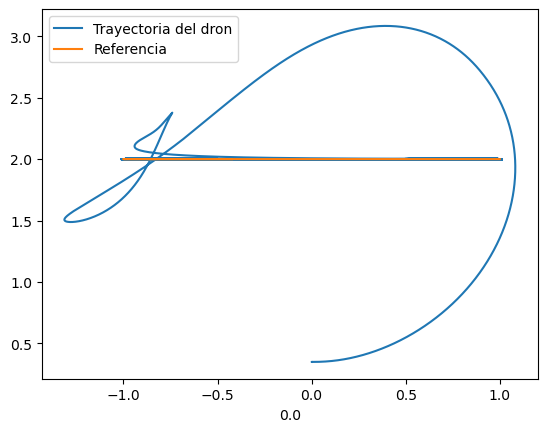

In [ ]:
import numpy as np
import mujoco
from mujoco import viewer
import time
from low_level_controller.mellinguer import MellinguerController
from low_level_controller.indi import INDIController
from helper import ForceArrow, PointMarker, quat_to_rotmat
from plot import plot_trajectory, plot_traj_and_ref

from acceleration_estimator import AccelerationEstimator
from force_observer.force_observer import ForceObserver
from force_observer.force_filter import MovingAverageForgettingFactorFilter

from path_generator import PathGenerator



# --- XML con actuadores directos u1,u2,u3,u4 ---
XML_PATH = "system/drone_bar_sphere_obs_u1234.xml"  # <-- pon aquí tu nuevo XML

model = mujoco.MjModel.from_xml_path(XML_PATH)
data = mujoco.MjData(model)
dt = model.opt.timestep

arrowVF = ForceArrow(model, data, arrow_idx=1) # virtual force (mocap)
arrowEF = ForceArrow(model, data, arrow_idx=2) # estimated force (mocap)
markerT = PointMarker(model, data, marker_idx=1) # referencia deseada (mocap)

# Body del dron
drone_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "drone_3d")
if drone_id < 0:
    raise ValueError("No existe el body 'drone_3d' en el XML.")

# Masa total del dron
m = float(model.body_subtreemass[drone_id])

# Posición inicial para hover
mujoco.mj_forward(model, data)
p0 = data.xpos[drone_id].copy()

# Gains como lista: [Kp_pos, Kv_pos, KR_att, Komega_att]
gains = [
    np.array([5.0, 5.0, 10.0]),         # Kp posición (diag)
    np.array([3.0, 3.0, 6.0]),          # Kv velocidad (diag)
    np.array([8.0, 8.0, 2.0]),    # KR actitud (diag)
    np.array([0.2, 0.2, 0.1])         # Komega velocidad angular (diag)
]

controller = MellinguerController(mass=m, gravity=9.81, gains=gains)


# (Opcional) si quieres asignar por nombre para evitar depender del orden:
act_u1 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u1_thrust")
act_u2 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u2_tau_x")
act_u3 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u3_tau_y")
act_u4 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u4_tau_z")
if min(act_u1, act_u2, act_u3, act_u4) < 0:
    raise ValueError("No encontré actuadores u1_thrust/u2_tau_x/u3_tau_y/u4_tau_z. Revisa el XML.")


# Inicializar estimador de aceleración, observador de fuerza y filtro de fuerza
acceleration_estimator = AccelerationEstimator(dt)
force_observer = ForceObserver(drone_mass=m, gravity=9.81)
force_filter = MovingAverageForgettingFactorFilter(window_size=15, forgetting_factor=0.9)
path_generator = PathGenerator()

# guardar para debug/visualización
vector_r = []
vector_rT = []
# Fe inicial
Fe_filt = np.zeros(3)

with viewer.launch_passive(model, data) as vis:
    t = 0.0

    while vis.is_running():
        # ---------------------------
        # (1) Leer estado en MuJoCo
        # ---------------------------
        r = data.xpos[drone_id].copy()
        q = data.xquat[drone_id].copy()
        R = quat_to_rotmat(q)

        # cvel = [wx, wy, wz, vx, vy, vz] (world-aligned)
        cvel = data.cvel[drone_id].copy()
        omega_world = cvel[0:3]
        vel_world = cvel[3:6]

        # aceleración estimada (derivada numérica)
        a = acceleration_estimator.estimate(vel_world, noise=False, noise_std=1.5)

        # Tu controlador típicamente usa omega en body
        omega_body = R.T @ omega_world

        # ---------------------------
        # (2) Referencia deseada (ejemplo: oscilación en x)
        # ---------------------------
        # x_d = 1.5 #0.5 * np.sin(0.5 * t)
        # x_dot_d = 0 #0.25 * np.cos(0.5 * t)
        # x_ddot_d = 0 #-0.125 * np.sin(0.5 * t)

        # rT = np.array([p0[0] + x_d, p0[1], 2.0])
        # vT = np.array([x_dot_d, 0.0, 0.0])
        # aT = np.array([x_ddot_d, 0.0, 0.0])

        # rT, vT, aT = path_generator.fixed_point([1.0, 0.0, 2.0])
        # rT, vT, aT = path_generator.do_circle_xz(t, radius=0.5, center=np.array([1.0, 0.0, 1.5]), omega=1.0)
        # rT, vT, aT = path_generator.do_circle_xy(t, radius=0.5, center=np.array([1.0, 0.0, 1.5]), omega=1.0)
        rT, vT, aT = path_generator.do_circle_xy(t, radius=1.0, center=np.array([0.0, 0.0, 2.0]), omega=1.0)
        # rT, vT, aT = path_generator.do_sine_x(t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.3, frequency=1.0)
        # rT, vT, aT = path_generator.do_square_xz(t, center=np.array([1.0, 0.0, 2.0]), side_length=0.5, omega=1.0)


        yaw_d = 0.0

        # guardar para debug/visualización
        vector_r.append(r)
        vector_rT.append(rT)

        # ---------------------------
        # (3) Control Mellinger -> u = [u1,u2,u3,u4]
        # ---------------------------

        u, Fv, _ = controller.step(rT, vT, aT, r, vel_world, a, R, omega_body, yaw_d, f_ext=Fe_filt)

        Fe = force_observer.observe(u1_sclr=u[0], drone_acceleration=a, R=R)
        Fe_filt = force_filter.filter(Fe)

        # ---------------------------
        # (4) Aplicar controles directo a actuadores
        # ---------------------------
        data.ctrl[act_u1] = u[0]
        data.ctrl[act_u2] = u[1]
        data.ctrl[act_u3] = u[2]
        data.ctrl[act_u4] = u[3]

        # ---------------------------
        # (5) Actualizar flechas de fuerza / estimar fuerza real / actualizar marker de referencia
        # ---------------------------

        if arrowVF is not None:
            arrowVF.update_force_arrow_mocap(p0_world=r, F_world=Fv, scale=0.03, max_len=0.8, radius=0.01)

        if arrowEF is not None:
            arrowEF.update_force_arrow_mocap(p0_world=r, F_world=Fe_filt, scale=0.03, max_len=0.8, radius=0.01)

        if markerT is not None:
            markerT.update_point(p_world=rT, radius=0.01)

        # ---------------------------
        # (6) Paso de simulación
        # ---------------------------
        start = time.time()

        mujoco.mj_step(model, data)
        vis.sync()
        t += dt

        alpha = 0  # factor de ajuste para sincronización (puedes experimentar con valores <1.0 si el código de control es muy pesado)

        # sincronizar en tiempo real
        elapsed = time.time() - start
        sleep_time = (dt - elapsed)*alpha
        if sleep_time > 0:
            time.sleep(sleep_time)


# # visualización de trayectoria (opcional)
vector_r = np.array(vector_r)
vector_rT = np.array(vector_rT)
# plot_trajectory(vector_r[:,0], vector_r[:,2], p0[0])
plot_traj_and_ref(vector_r[:,0], vector_r[:,2], vector_rT[:,0], vector_rT[:,2], p0[0])


# # visualización de trayectoria (opcional)
# import matplotlib.pyplot as plt
# vector_r = np.array(vector_r)
# plt.figure()
# plt.plot(vector_r[:,0], vector_r[:,2], label='Trayectoria del dron')
# plt.xlabel('x (m)')
# plt.ylabel('z (m)')

# #ajustar límites y agregar referencia deseada
# # plt.xlim(p0[0] - 1, p0[0] + 1)
# # plt.ylim(p0[2] - 1, p0[2] + 1)

# plt.legend()
# plt.show()


# Fixed Spring to Quadrotor 

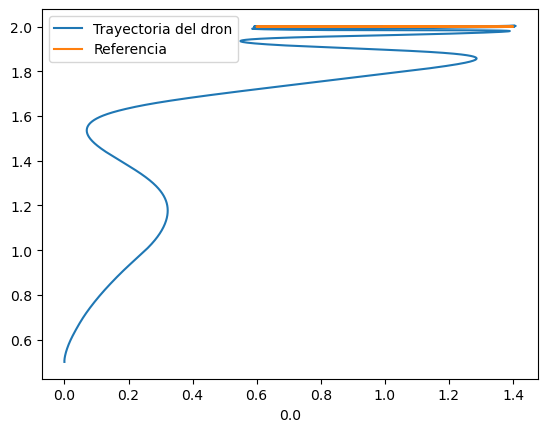

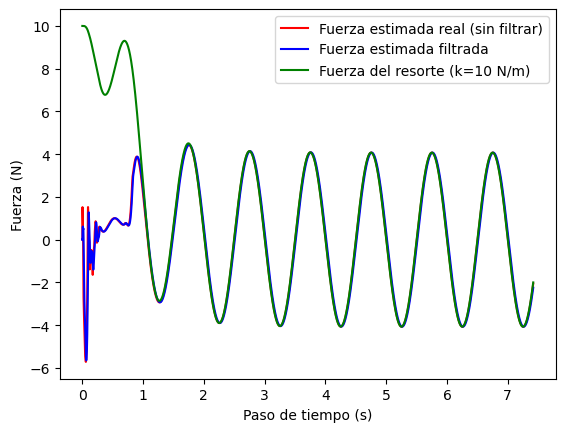

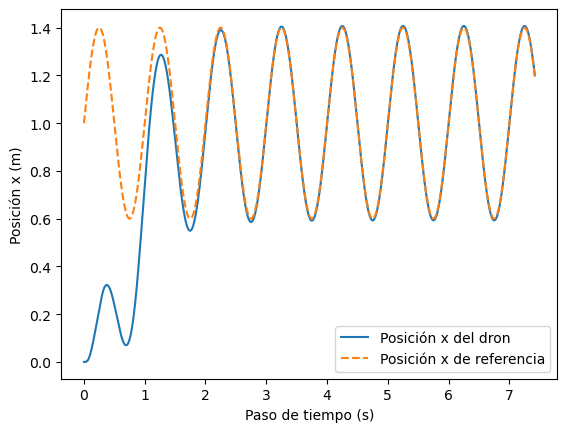

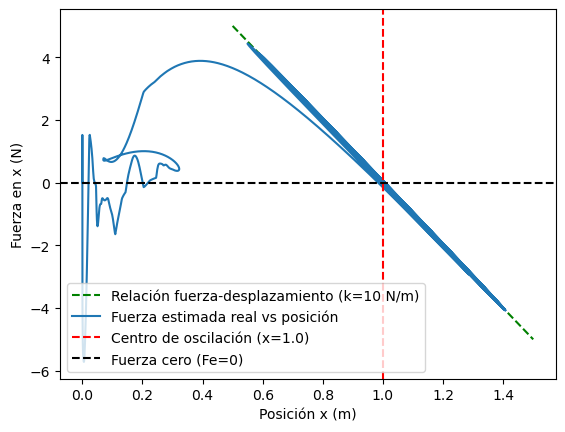

In [18]:
import numpy as np
import mujoco
from mujoco import viewer
import time
import matplotlib.pyplot as plt
from low_level_controller.mellinguer import MellinguerController
from low_level_controller.indi import INDIController
from helper import ForceArrow, PointMarker, quat_to_rotmat
from plot import plot_force_vs_time, plot_trajectory, plot_traj_and_ref

from acceleration_estimator import AccelerationEstimator
from force_observer.force_observer import ForceObserver
from force_observer.force_filter import MovingAverageForgettingFactorFilter

from path_generator import PathGenerator



# --- XML con actuadores directos u1,u2,u3,u4 ---
XML_PATH = "system/drone_spring_sphere_obs_u1234.xml"  # <-- pon aquí tu nuevo XML

model = mujoco.MjModel.from_xml_path(XML_PATH)
data = mujoco.MjData(model)
dt = model.opt.timestep

arrowVF = ForceArrow(model, data, arrow_idx=1) # virtual force (mocap)
arrowEF = ForceArrow(model, data, arrow_idx=2) # estimated force (mocap)
markerT = PointMarker(model, data, marker_idx=1) # referencia deseada (mocap)

# Body del dron
drone_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "drone_3d")
if drone_id < 0:
    raise ValueError("No existe el body 'drone_3d' en el XML.")

# Masa total del dron
m = float(model.body_subtreemass[drone_id])

# Posición inicial para hover
mujoco.mj_forward(model, data)
p0 = data.xpos[drone_id].copy()

# Gains como lista: [Kp_pos, Kv_pos, KR_att, Komega_att]
gains = [
    np.array([5.0, 5.0, 10.0]),         # Kp posición (diag)
    np.array([3.0, 3.0, 6.0]),          # Kv velocidad (diag)
    np.array([8.0, 8.0, 2.0]),    # KR actitud (diag)
    np.array([0.2, 0.2, 0.1])         # Komega velocidad angular (diag)
]

controller = MellinguerController(mass=m, gravity=9.81, gains=gains)


# (Opcional) si quieres asignar por nombre para evitar depender del orden:
act_u1 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u1_thrust")
act_u2 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u2_tau_x")
act_u3 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u3_tau_y")
act_u4 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u4_tau_z")
if min(act_u1, act_u2, act_u3, act_u4) < 0:
    raise ValueError("No encontré actuadores u1_thrust/u2_tau_x/u3_tau_y/u4_tau_z. Revisa el XML.")


# Inicializar estimador de aceleración, observador de fuerza y filtro de fuerza
acceleration_estimator = AccelerationEstimator(dt)
force_observer = ForceObserver(drone_mass=m, gravity=9.81)
force_filter = MovingAverageForgettingFactorFilter(window_size=15, forgetting_factor=0.9)
path_generator = PathGenerator()

# guardar para debug/visualización
vector_r = []
vector_rT = []
vector_Fe = [] # para guardar la fuerza estimada real (sin filtrar)
vector_Fe_filt = [] # para guardar la fuerza estimada filtrada para comparar
# Fe inicial
Fe_filt = np.zeros(3)
Fe = np.zeros(3)

with viewer.launch_passive(model, data) as vis:
    t = 0.0

    while vis.is_running():
        # ---------------------------
        # (1) Leer estado en MuJoCo
        # ---------------------------
        r = data.xpos[drone_id].copy()
        q = data.xquat[drone_id].copy()
        R = quat_to_rotmat(q)

        # cvel = [wx, wy, wz, vx, vy, vz] (world-aligned)
        cvel = data.cvel[drone_id].copy()
        omega_world = cvel[0:3]
        vel_world = cvel[3:6]

        # aceleración estimada (derivada numérica)
        a = acceleration_estimator.estimate(vel_world, noise=False, noise_std=1.5)

        # Tu controlador típicamente usa omega en body
        omega_body = R.T @ omega_world

        # ---------------------------
        # (2) Referencia deseada (ejemplo: oscilación en x)
        # ---------------------------
        # x_d = 1.5 #0.5 * np.sin(0.5 * t)
        # x_dot_d = 0 #0.25 * np.cos(0.5 * t)
        # x_ddot_d = 0 #-0.125 * np.sin(0.5 * t)

        # rT = np.array([p0[0] + x_d, p0[1], 2.0])
        # vT = np.array([x_dot_d, 0.0, 0.0])
        # aT = np.array([x_ddot_d, 0.0, 0.0])

        # rT, vT, aT = path_generator.fixed_point([1.0, 0.0, 2.0])
        # rT, vT, aT = path_generator.do_circle_xz(t, radius=0.5, center=np.array([1.0, 0.0, 1.5]), omega=1.0)
        # rT, vT, aT = path_generator.do_circle_xy(t, radius=0.5, center=np.array([1.0, 0.0, 1.5]), omega=1.0)
        # rT, vT, aT = path_generator.do_circle_xy(t, radius=1.0, center=np.array([0.0, 0.0, 2.0]), omega=1.0)
        rT, vT, aT = path_generator.do_sine_x(t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.4, frequency=1.0)
        # rT, vT, aT = path_generator.do_square_xz(t, center=np.array([1.0, 0.0, 2.0]), side_length=0.5, omega=1.0)
        # rT, vT, aT = path_generator.do_sine_x(t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.4, frequency=1 + t*0.1) # chirp para probar respuesta a frecuencias variables
        # rT, vT, aT = path_generator.do_square_signal_x(t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.4, frequency=0.2)


        yaw_d = 0.0

        # guardar para debug/visualización
        vector_r.append(r)
        vector_rT.append(rT)
        vector_Fe.append(Fe) # guardar la fuerza estimada real (sin filtrar)
        vector_Fe_filt.append(Fe_filt) # guardar la fuerza estimada filtrada para comparar

        # ---------------------------
        # (3) Control Mellinger -> u = [u1,u2,u3,u4]
        # ---------------------------

        u, Fv, _ = controller.step(rT, vT, aT, r, vel_world, a, R, omega_body, yaw_d, f_ext=Fe_filt)

        Fe = force_observer.observe(u1_sclr=u[0], drone_acceleration=a, R=R)
        # Fe = force_observer.observe_out(F_des=Fv, a=a)
        Fe_filt = force_filter.filter(Fe, limit=True, max_force=10.0) # limitar fuerza filtrada para evitar valores extremos que rompan la simulación

        # ---------------------------
        # (4) Aplicar controles directo a actuadores
        # ---------------------------
        data.ctrl[act_u1] = u[0]
        data.ctrl[act_u2] = u[1]
        data.ctrl[act_u3] = u[2]
        data.ctrl[act_u4] = u[3]

        # ---------------------------
        # (5) Actualizar flechas de fuerza / estimar fuerza real / actualizar marker de referencia
        # ---------------------------

        if arrowVF is not None:
            arrowVF.update_force_arrow_mocap(p0_world=r, F_world=Fv, scale=0.03, max_len=0.8, radius=0.01)

        if arrowEF is not None:
            arrowEF.update_force_arrow_mocap(p0_world=r, F_world=Fe_filt, scale=0.03, max_len=0.8, radius=0.01)

        if markerT is not None:
            markerT.update_point(p_world=rT, radius=0.01)

        # ---------------------------
        # (6) Paso de simulación
        # ---------------------------
        start = time.time()

        mujoco.mj_step(model, data)
        vis.sync()
        t += dt

        alpha = 1  # factor de ajuste para sincronización (puedes experimentar con valores <1.0 si el código de control es muy pesado)

        # sincronizar en tiempo real
        elapsed = time.time() - start
        sleep_time = (dt - elapsed)*alpha
        if sleep_time > 0:
            time.sleep(sleep_time)


# # visualización de trayectoria (opcional)
vector_r = np.array(vector_r)
vector_rT = np.array(vector_rT)
vector_Fe = np.array(vector_Fe)
vector_Fe_filt = np.array(vector_Fe_filt)

# plot_trajectory(vector_r[:,0], vector_r[:,2], p0[0])
plot_traj_and_ref(vector_r[:,0], vector_r[:,2], vector_rT[:,0], vector_rT[:,2], p0[0])


# visualización de fuerza estimada real (sin filtrar)
#eje de tiempo
axt = np.linspace(0, len(vector_Fe)*dt, len(vector_Fe))
vector_F_spring = -10.0 * (vector_r[:,0] - 1.0) # fuerza del resorte (k=10 N/m, x0=1.0)
plot_force_vs_time(axt, vector_Fe[:,0], 'Fuerza estimada real (sin filtrar)', '-', 'red',
                      vector_Fe_filt[:,0], 'Fuerza estimada filtrada', '-', 'blue',
                      vector_F_spring, 'Fuerza del resorte (k=10 N/m)', '-', 'green')


# Visualizacion de posicion x con respecto al tiempo
plt.figure()
plt.plot(axt, vector_r[:,0], label='Posición x del dron')
plt.plot(axt, vector_rT[:,0], label='Posición x de referencia', linestyle='--')
plt.xlabel('Paso de tiempo (s)')
plt.ylabel('Posición x (m)')
plt.legend()
plt.show()


# visualización de fuerza estimada real vs posición
plt.figure()
# trazar recta y=-k*(x-1.0) para visualizar relación fuerza-desplazamiento (con k=10 N/m)
k = 10.0
x_vals = np.linspace(0.5, 1.5, 100)
y_vals = -k * (x_vals - 1.0)
plt.plot(x_vals, y_vals, 'g--', label='Relación fuerza-desplazamiento (k=10 N/m)')
# trazar fuerza estimada real vs posición x
plt.plot(vector_r[:,0], vector_Fe[:,0], label='Fuerza estimada real vs posición')
# trazar linea vertical en x = 1.0 (centro de oscilación)
plt.axvline(x=1.0, color='r', linestyle='--', label='Centro de oscilación (x=1.0)')
# trazar linea horizontal en Fe=0
plt.axhline(y=0.0, color='k', linestyle='--', label='Fuerza cero (Fe=0)')

plt.xlabel('Posición x (m)')
plt.ylabel('Fuerza en x (N)')
plt.legend()
plt.show()

# Two Quadrotors
Test with two quadrotors. One leader and one follower (position control), or two leaders (passive velocity control only)

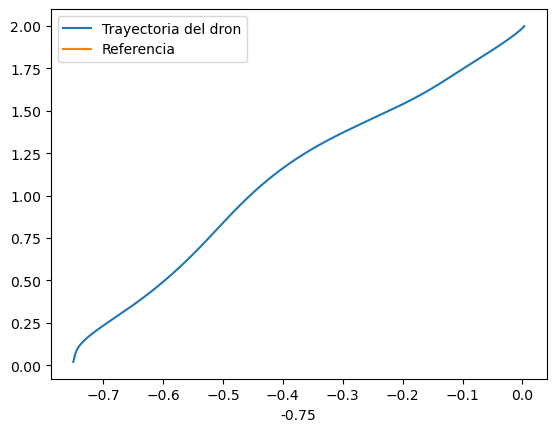

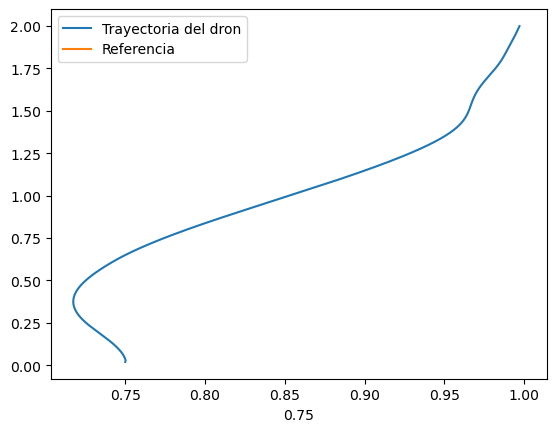

In [47]:
import numpy as np
import mujoco
from mujoco import viewer
import time
from low_level_controller.mellinguer import MellinguerController
from low_level_controller.indi import INDIController
from helper import ForceArrow, PointMarker, quat_to_rotmat
from plot import plot_trajectory, plot_traj_and_ref

from acceleration_estimator import AccelerationEstimator
from force_observer.force_observer import ForceObserver
from force_observer.force_filter import MovingAverageForgettingFactorFilter

from path_generator import PathGenerator



# --- XML con actuadores directos u1,u2,u3,u4 ---
XML_PATH = "system/drone_bar_drone_obs_u1234.xml"  # <-- pon aquí tu nuevo XML

model = mujoco.MjModel.from_xml_path(XML_PATH)
data = mujoco.MjData(model)
dt = model.opt.timestep
#drone 1
arrowVF_1 = ForceArrow(model, data, arrow_idx=1) # virtual force (mocap)
arrowEF_1 = ForceArrow(model, data, arrow_idx=2) # estimated force (mocap)
markerT_1 = PointMarker(model, data, marker_idx=1) # referencia deseada (mocap)
#drone 2
arrowVF_2 = ForceArrow(model, data, arrow_idx=3) # virtual force (mocap)
arrowEF_2 = ForceArrow(model, data, arrow_idx=4) # estimated force (mocap)
markerT_2 = PointMarker(model, data, marker_idx=2) # referencia deseada (mocap)

# Body del dron
drone_id_1 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "drone_A")
if drone_id_1 < 0:
    raise ValueError("No existe el body 'drone_A' en el XML.")
drone_id_2 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "drone_B")
if drone_id_2 < 0:
    raise ValueError("No existe el body 'drone_B' en el XML.")

# Masa total del dron
m1 = float(model.body_subtreemass[drone_id_1])
m2 = float(model.body_subtreemass[drone_id_2])

# Posición inicial para hover
mujoco.mj_forward(model, data)
p0_1 = data.xpos[drone_id_1].copy()
p0_2 = data.xpos[drone_id_2].copy()

# Gains como lista: [Kp_pos, Kv_pos, KR_att, Komega_att]
gains = [
    np.array([5.0, 5.0, 10.0]),         # Kp posición (diag)
    np.array([3.0, 3.0, 6.0]),          # Kv velocidad (diag)
    np.array([8.0, 8.0, 2.0]),    # KR actitud (diag)
    np.array([0.2, 0.2, 0.1])         # Komega velocidad angular (diag)
]

controller_1 = MellinguerController(mass=m1, gravity=9.81, gains=gains)
controller_2 = MellinguerController(mass=m2, gravity=9.81, gains=gains)


# (Opcional) si quieres asignar por nombre para evitar depender del orden:
act_u1_1 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "uA1_thrust")
act_u2_1 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "uA2_tau_x")
act_u3_1 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "uA3_tau_y")
act_u4_1 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "uA4_tau_z")

act_u1_2 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "uB1_thrust")
act_u2_2 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "uB2_tau_x")
act_u3_2 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "uB3_tau_y")
act_u4_2 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "uB4_tau_z")
if min(act_u1_1, act_u2_1, act_u3_1, act_u4_1, act_u1_2, act_u2_2, act_u3_2, act_u4_2) < 0:
    raise ValueError("No encontré los actuadores uA1_thrust/uA2_tau_x/uA3_tau_y/uA4_tau_z/uB1_thrust/uB2_tau_x/uB3_tau_y/uB4_tau_z. Revisa el XML.")





# Inicializar estimador de aceleración, observador de fuerza y filtro de fuerza
acceleration_estimator_1 = AccelerationEstimator(dt)
acceleration_estimator_2 = AccelerationEstimator(dt)
force_observer_1 = ForceObserver(drone_mass=m1, gravity=9.81)
force_observer_2 = ForceObserver(drone_mass=m2, gravity=9.81)
force_filter_1 = MovingAverageForgettingFactorFilter(window_size=15, forgetting_factor=0.9)
force_filter_2 = MovingAverageForgettingFactorFilter(window_size=15, forgetting_factor=0.9)
path_generator_1 = PathGenerator()
path_generator_2 = PathGenerator()

# guardar para debug/visualización
vector_r_1 = []
vector_r_2 = []
vector_rT_1 = []
vector_rT_2 = []
# Fe inicial
Fe_filt_1 = np.zeros(3)
Fe_filt_2 = np.zeros(3)

with viewer.launch_passive(model, data) as vis:
    t = 0.0

    while vis.is_running():
        # ---------------------------
        # (1) Leer estado en MuJoCo
        # ---------------------------
        r_1 = data.xpos[drone_id_1].copy()
        q_1 = data.xquat[drone_id_1].copy()
        R_1 = quat_to_rotmat(q_1)
        r_2 = data.xpos[drone_id_2].copy()
        q_2 = data.xquat[drone_id_2].copy()
        R_2 = quat_to_rotmat(q_2)

        # cvel = [wx, wy, wz, vx, vy, vz] (world-aligned)
        cvel_1 = data.cvel[drone_id_1].copy()
        omega_world_1 = cvel_1[0:3]
        vel_world_1 = cvel_1[3:6]

        cvel_2 = data.cvel[drone_id_2].copy()
        omega_world_2 = cvel_2[0:3]
        vel_world_2 = cvel_2[3:6]

        # aceleración estimada (derivada numérica)
        a_1 = acceleration_estimator_1.estimate(vel_world_1, noise=False, noise_std=1.5)
        a_2 = acceleration_estimator_2.estimate(vel_world_2, noise=False, noise_std=1.5)

        # Tu controlador típicamente usa omega en body
        omega_body_1 = R_1.T @ omega_world_1
        omega_body_2 = R_2.T @ omega_world_2

        # ---------------------------
        # (2) Referencia deseada (ejemplo: oscilación en x)
        # ---------------------------
        # x_d = 1.5 #0.5 * np.sin(0.5 * t)
        # x_dot_d = 0 #0.25 * np.cos(0.5 * t)
        # x_ddot_d = 0 #-0.125 * np.sin(0.5 * t)

        # rT = np.array([p0[0] + x_d, p0[1], 2.0])
        # vT = np.array([x_dot_d, 0.0, 0.0])
        # aT = np.array([x_ddot_d, 0.0, 0.0])

        # rT, vT, aT = path_generator.fixed_point([1.0, 0.0, 2.0])
        # rT, vT, aT = path_generator.do_circle_xz(t, radius=0.5, center=np.array([1.0, 0.0, 1.5]), omega=1.0)
        # rT, vT, aT = path_generator.do_circle_xy(t, radius=0.5, center=np.array([1.0, 0.0, 1.5]), omega=1.0)
        # rT, vT, aT = path_generator.do_circle_xy(t, radius=1.0, center=np.array([0.0, 0.0, 2.0]), omega=1.0)
        # rT, vT, aT = path_generator.do_sine_x(t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.3, frequency=1.0)
        # rT, vT, aT = path_generator.do_square_xz(t, center=np.array([1.0, 0.0, 2.0]), side_length=0.5, omega=1.0)

        
        # # drone 1 fixed
        # rT_1, vT_1, aT_1 = path_generator_1.fixed_point([0.0, 0.0, 2.0])
        # # drone 2 moving
        # rT_2, vT_2, aT_2 = path_generator_2.do_sine_x(t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.3, frequency=0.2)

        # # ambos oscilando
        # rT_1, vT_1, aT_1 = path_generator_1.do_sine_x(t, center=np.array([0.0, 0.0, 2.0]), amplitude=0.2, frequency=0.1)
        # rT_2, vT_2, aT_2 = path_generator_2.do_sine_x(-t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.2, frequency=0.2)

        # # Fijo y cuadrado
        # rT_1, vT_1, aT_1 = path_generator_1.fixed_point([0.0, 0.0, 2.0])
        # rT_2, vT_2, aT_2 = path_generator_2.do_square_xz(t, center=np.array([1.0, 0.0, 2.0]), side_length=0.5, omega=0.5)

        # Ambos fijos
        rT_1, vT_1, aT_1 = path_generator_1.fixed_point([0.0, 0.0, 2.0])
        rT_2, vT_2, aT_2 = path_generator_2.fixed_point([1.0, 0.0, 2.0])


        yaw_d_1 = 0.0
        yaw_d_2 = 0.0

        # guardar para debug/visualización
        vector_r_1.append(r_1)
        vector_r_2.append(r_2)
        vector_rT_1.append(rT_1)
        vector_rT_2.append(rT_2)

        # ---------------------------
        # (3) Control Mellinger -> u = [u1,u2,u3,u4]
        # ---------------------------

        u_1, Fv_1, _ = controller_1.step(rT_1, vT_1, aT_1, r_1, vel_world_1, a_1, R_1, omega_body_1, yaw_d_1, f_ext=Fe_filt_1)
        u_2, Fv_2, _ = controller_2.step(rT_2, vT_2, aT_2, r_2, vel_world_2, a_2, R_2, omega_body_2, yaw_d_2, f_ext=Fe_filt_2)

        Fe_1 = force_observer_1.observe(u1_sclr=u_1[0], drone_acceleration=a_1, R=R_1)
        Fe_2 = force_observer_2.observe(u1_sclr=u_2[0], drone_acceleration=a_2, R=R_2)

        Fe_filt_1 = force_filter_1.filter(Fe_1, limit=True, max_force=10.0)
        Fe_filt_2 = force_filter_2.filter(Fe_2, limit=True, max_force=10.0)

        # ---------------------------
        # (4) Aplicar controles directo a actuadores
        # ---------------------------
        data.ctrl[act_u1_1] = u_1[0]
        data.ctrl[act_u2_1] = u_1[1]
        data.ctrl[act_u3_1] = u_1[2]
        data.ctrl[act_u4_1] = u_1[3]
        data.ctrl[act_u1_2] = u_2[0]
        data.ctrl[act_u2_2] = u_2[1]
        data.ctrl[act_u3_2] = u_2[2]
        data.ctrl[act_u4_2] = u_2[3]

        # ---------------------------
        # (5) Actualizar flechas de fuerza / estimar fuerza real / actualizar marker de referencia
        # ---------------------------

        if arrowVF_1 is not None:
            arrowVF_1.update_force_arrow_mocap(p0_world=r_1, F_world=Fv_1, scale=0.03, max_len=0.8, radius=0.01)
        if arrowEF_1 is not None:
            arrowEF_1.update_force_arrow_mocap(p0_world=r_1, F_world=Fe_filt_1, scale=0.03, max_len=0.8, radius=0.01)
        if markerT_1 is not None:
            markerT_1.update_point(p_world=rT_1, radius=0.01)

        if arrowVF_2 is not None:
            arrowVF_2.update_force_arrow_mocap(p0_world=r_2, F_world=Fv_2, scale=0.03, max_len=0.8, radius=0.01)
        if arrowEF_2 is not None:
            arrowEF_2.update_force_arrow_mocap(p0_world=r_2, F_world=Fe_filt_2, scale=0.03, max_len=0.8, radius=0.01)
        if markerT_2 is not None:
            markerT_2.update_point(p_world=rT_2, radius=0.01)

        # ---------------------------
        # (6) Paso de simulación
        # ---------------------------
        start = time.time()

        mujoco.mj_step(model, data)
        vis.sync()
        t += dt

        # alpha = 1e-1  # factor de ajuste para sincronización (puedes experimentar con valores <1.0 si el código de control es muy pesado)

        # # sincronizar en tiempo real
        # elapsed = time.time() - start
        # sleep_time = (dt - elapsed)*alpha
        # if sleep_time > 0:
        #     time.sleep(sleep_time)

        time.sleep(0.25e-323)  # sleep fijo para evitar correr demasiado rápido (ajusta según tu CPU/GPU)


# # visualización de trayectoria (opcional)
vector_r_1 = np.array(vector_r_1)
vector_rT_1 = np.array(vector_rT_1)
vector_r_2 = np.array(vector_r_2)
vector_rT_2 = np.array(vector_rT_2)
# plot_trajectory(vector_r[:,0], vector_r[:,2], p0[0])
plot_traj_and_ref(vector_r_1[:,0], vector_r_1[:,2], vector_rT_1[:,0], vector_rT_1[:,2], p0_1[0])
plot_traj_and_ref(vector_r_2[:,0], vector_r_2[:,2], vector_rT_2[:,0], vector_rT_2[:,2], p0_2[0])



# 